In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [15]:
# 자동차 연비 데이터 분석 
mpg_df = pd.read_excel("datasets/auto_mpg.xlsx")
mpg_df.info()
mpg_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           481 non-null    float64
 1   cylinders     496 non-null    float64
 2   displacement  492 non-null    float64
 3   horsepower    491 non-null    float64
 4   weight        490 non-null    float64
 5   acceleration  492 non-null    float64
 6   model_year    496 non-null    float64
 7   origin        498 non-null    int64  
 8   name          498 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 35.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino


In [19]:
# 칼럼명 변경
mpg_df.rename(columns={
    'mpg': '연비',
    'cylinders': '실린더 수', 
    'displacement': '배기량',
    'horsepower': '마력', 
    'weight': '차량 무게', 
    'acceleration': '가속 성능', 
    'model_year': '차량 출시 연도', 
    'origin': '제조 국가 코드', 
    'name': '차량 이름'
}, inplace=True)
mpg_df

,연비,실린더 수,배기량,마력,차량 무게,가속 성능,차량 출시 연도,제조 국가 코드,차량 이름
0,18.00,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.00,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.00,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.00,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.00,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino
...,...,...,...,...,...,...,...,...,...
493,121.98,6.0,385.0,167.0,4645.0,19.6,71.0,2,zenith model 605
494,146.52,4.0,387.0,173.0,4511.0,20.6,76.0,1,lynx model 651
495,NaN,6.0,363.0,171.0,4455.0,20.7,70.0,3,vesta model 826
496,135.13,6.0,378.0,178.0,4539.0,20.6,70.0,1,lynx model 477


In [20]:
# 결측치 처리
# 연비, 실린더 수, 배기량, 마력, 차량 무게, 가속 성능, 차량 출시 연도
mpg_df.isna().sum()

del_df = mpg_df.dropna()
print(del_df.isna().sum())

연비          0
실린더 수       0
배기량         0
마력          0
차량 무게       0
가속 성능       0
차량 출시 연도    0
제조 국가 코드    0
차량 이름       0
dtype: int64


<Axes: xlabel='마력', ylabel='연비'>

C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47141 

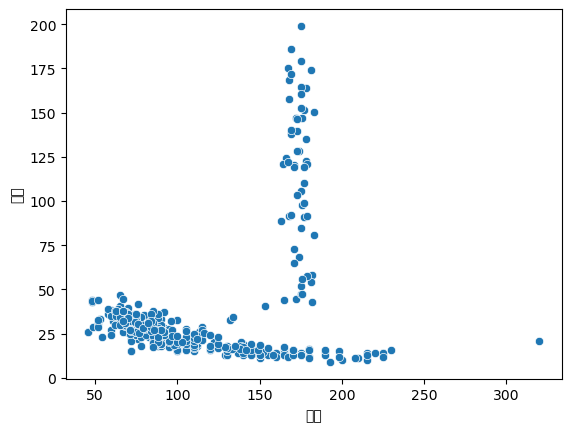

In [21]:
# 시각화
sns.scatterplot(data=del_df, x='마력', y='연비')

In [24]:
# 이상치 제거
result = (del_df['마력'] >= 150) & (del_df['연비'] > 50)
# print(del_df[result])
del_df.drop(del_df[result].index, axis=0, inplace=True)
del_df

C:\Users\LG\AppData\Local\Temp\ipykernel_20812\2486727066.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del_df.drop(del_df[result].index, axis=0, inplace=True)


,연비,실린더 수,배기량,마력,차량 무게,가속 성능,차량 출시 연도,제조 국가 코드,차량 이름
0,18.00,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.00,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.00,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.00,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.00,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino
...,...,...,...,...,...,...,...,...,...
429,43.88,4.0,380.0,165.0,4621.0,20.1,73.0,1,zenith model 873
451,44.78,8.0,376.0,172.0,4565.0,19.9,77.0,1,aether model 894
460,42.88,4.0,394.0,182.0,4606.0,20.1,77.0,1,aether model 172
463,47.21,4.0,386.0,175.0,4509.0,20.5,70.0,1,lynx model 730


            배기량        마력     차량 무게     가속 성능
배기량    1.000000  0.859654  0.935449 -0.487637
마력     0.859654  1.000000  0.826202 -0.592745
차량 무게  0.935449  0.826202  1.000000 -0.362986
가속 성능 -0.487637 -0.592745 -0.362986  1.000000


C:\Users\LG\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


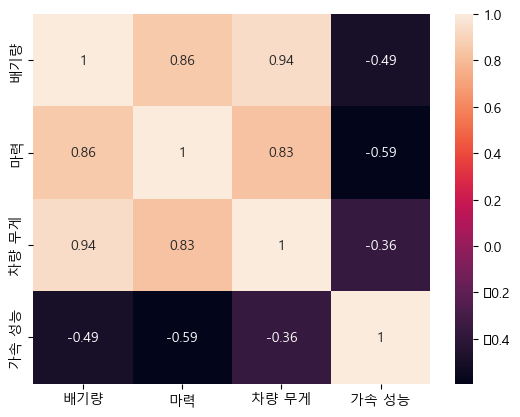

In [28]:
# 연속형 변수간의 관계
col_list = ['배기량', '마력', '차량 무게', '가속 성능']
corr = del_df[col_list].corr()
print(corr)

# 시각화
plt.rc('font', family='Malgun Gothic')
sns.heatmap(data=del_df[col_list].corr(), annot=True)
답변06 = 3

In [29]:
# 칼럼 삭제
del_cols = ['차량 무게', '차량 출시 연도', '제조 국가 코드', '차량 이름']
clear_df = del_df.drop(del_cols, axis=1)
clear_df

,연비,실린더 수,배기량,마력,가속 성능
0,18.00,8.0,307.0,130.0,12.0
1,15.00,8.0,350.0,165.0,11.5
2,18.00,8.0,318.0,150.0,11.0
3,16.00,8.0,304.0,150.0,12.0
4,17.00,8.0,302.0,140.0,10.5
...,...,...,...,...,...
429,43.88,4.0,380.0,165.0,20.1
451,44.78,8.0,376.0,172.0,19.9
460,42.88,4.0,394.0,182.0,20.1
463,47.21,4.0,386.0,175.0,20.5


In [31]:
# 원-핫 인코딩
encoding_df = pd.get_dummies(data=clear_df, columns=['실린더 수'], drop_first=True)
encoding_df

,연비,배기량,마력,가속 성능,실린더 수_4.0,실린더 수_5.0,실린더 수_6.0,실린더 수_8.0
0,18.00,307.0,130.0,12.0,False,False,False,True
1,15.00,350.0,165.0,11.5,False,False,False,True
2,18.00,318.0,150.0,11.0,False,False,False,True
3,16.00,304.0,150.0,12.0,False,False,False,True
4,17.00,302.0,140.0,10.5,False,False,False,True
...,...,...,...,...,...,...,...,...
429,43.88,380.0,165.0,20.1,True,False,False,False
451,44.78,376.0,172.0,19.9,False,False,False,True
460,42.88,394.0,182.0,20.1,True,False,False,False
463,47.21,386.0,175.0,20.5,True,False,False,False


In [51]:
# 데이터 분리
from sklearn.model_selection import train_test_split

Feature = encoding_df.drop('연비', axis=1)
Target = encoding_df['연비']
print(Feature.columns)

X_train, X_valid, y_train, y_valid = train_test_split(
    Feature, Target, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)

Index(['배기량', '마력', '가속 성능', '실린더 수_4.0', '실린더 수_5.0', '실린더 수_6.0',
       '실린더 수_8.0'],
      dtype='object')
(322, 7) (322,) (81, 7) (81,)


In [35]:
# 데이터 표준화 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)
print(X_test.shape)

(81, 7)


In [38]:
# 서포트 벡터 머신 모델
from sklearn.svm import SVR 

svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.2
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [40]:
# 랜덤 포레스트  회귀 모델
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=200, 
    max_depth=10, min_samples_split=7, random_state=42)

rfr.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# 딥러닝 모델
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
tf.random.set_seed(10)

In [48]:
# 모델 구조
model = Sequential()
model.add(Dense(32, activation='tanh', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(24, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='tanh'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(1, activation='linear'))

# 학습 설정
model.compile(
    optimizer='rmsprop',
    loss='mean_absolute_error',
    metrics=['mean_squared_error']
)

model.fit(X_train, y_train, epochs=50, batch_size=8)

Epoch 1/50


C:\Users\LG\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.2047 - mean_squared_error: 596.7096
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 22.1775 - mean_squared_error: 553.9840
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.0618 - mean_squared_error: 507.7949
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.1552 - mean_squared_error: 473.2798
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.5326 - mean_squared_error: 448.4151
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.0748 - mean_squared_error: 430.3966
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.6724 - mean_squared_error: 415.3010
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.2841 - mean_squared_error: 400.9498
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.9322 - mean_squared_error: 388.0142
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5196 - mean_squared_error: 372.8330
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0

In [50]:
# 예측
# ['배기량', '마력', '가속 성능', '실린더 수_4.0', '실린더 수_5.0', '실린더 수_6.0','실린더 수_8.0']
simul_data = np.array([[200.0, 95.0, 15.0, 1, 0, 0, 0]])
simul_data = scaler.transform(simul_data)
deep_pre = model.predict(simul_data)
deep_pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

C:\Users\LG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


array([[19.85945]], dtype=float32)